# Modules

In [3]:
from LC_utility import *

# Color Plot

In [6]:
### Read in Models
LCm2_i = pd.read_csv('../tables/LC_tables/M2_iEtaCarLC.csv')
LCm2_g = pd.read_csv('../tables/LC_tables/M2_gEtaCarLC.csv')

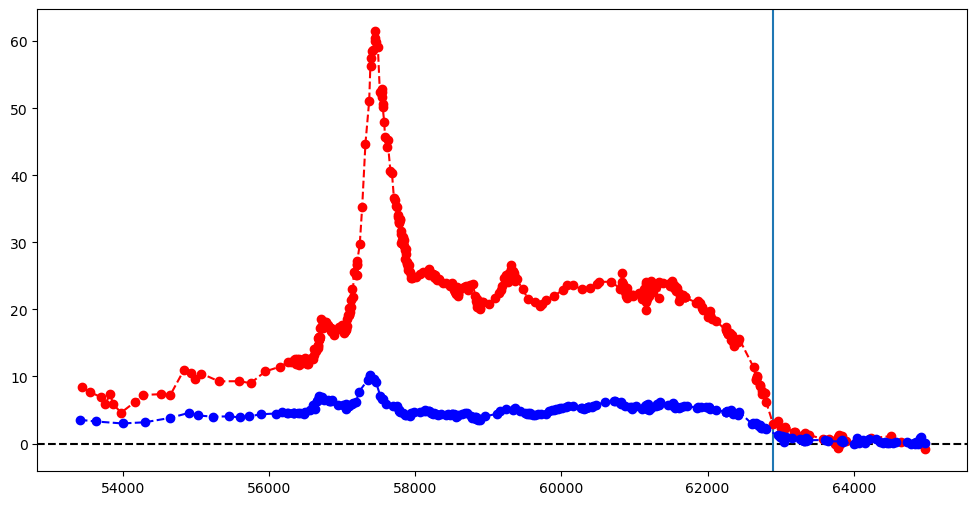

In [8]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(LCm2_i['mjd'], LCm2_i['mJyas2'], fmt='--o', ecolor='black', color='red', yerr=LCm2_i['mJyas2_err'])
plt.errorbar(LCm2_g['mjd'], LCm2_g['mJyas2'], fmt='--o', ecolor='black', color='blue', yerr=LCm2_g['mJyas2_err'])
plt.axhline(y=0, linestyle='--', color='black')
plt.axvline(x=62900)

In [10]:
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]

LCm2_i.loc[working_inds_i,'AB_mag'] = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values)
LCm2_g.loc[working_inds_g,'AB_mag'] = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values)

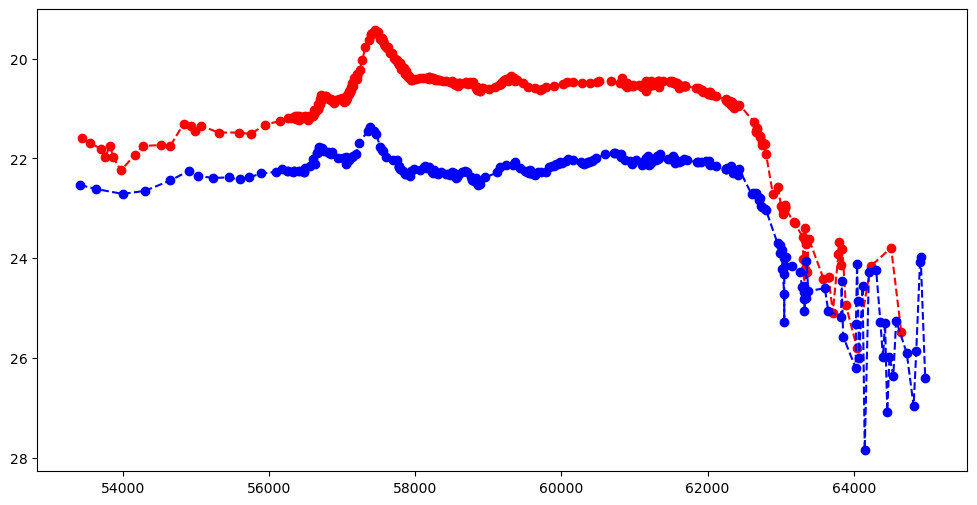

In [12]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], fmt='--o', ecolor='black', color='red')
plt.errorbar(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], fmt='--o', ecolor='black', color='blue')

# plt.errorbar(LCm2_i['mjd'], LCm2_i['AB_mag'], fmt='--o', ecolor='black', color='green')
# plt.errorbar(LCm2_g['mjd'], LCm2_g['AB_mag'], fmt='--o', ecolor='black', color='orange')

plt.gca().invert_yaxis()

In [28]:
# t_ran = np.arange(min(LCm2_g.loc[working_inds_g,'mjd']), max(LCm2_g.loc[working_inds_g,'mjd']))
t_ran = np.arange(min(LCm2_i.loc[working_inds_i,'mjd']), max(LCm2_i.loc[working_inds_i,'mjd']))

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

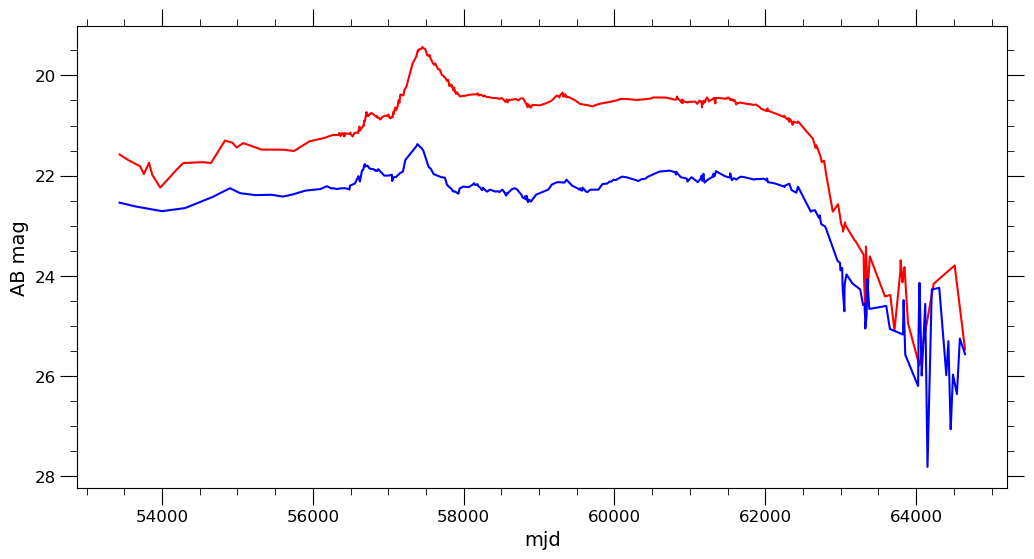

In [30]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.minorticks_on()
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
plt.gca().set_xlabel('mjd', fontsize = 14)
plt.gca().set_ylabel('AB mag', fontsize = 14)
plt.ticklabel_format(axis='both', style='plain')


plt.errorbar(t_ran, i_new, ecolor='black', color='red')
plt.errorbar(t_ran, g_new, ecolor='black', color='blue')
plt.gca().invert_yaxis()

# plt.axvline(54850, color='k', ls='--')
# plt.axvline(56740, color='k', ls='--')
# plt.axvline(57430, color='k', ls='--')
# plt.axvline(59300, color='k', ls='--')

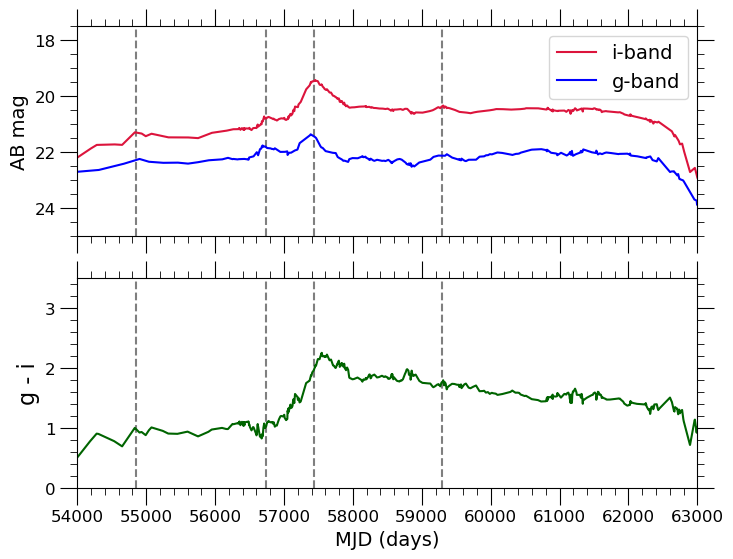

In [36]:
fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten() 
axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(t_ran, i_new, ecolor='black', color='crimson',label='i-band')
axs[0].errorbar(t_ran, g_new, ecolor='black', color='blue',label='g-band')

axs[0].axvline(54850, color='k', ls='--', alpha=0.5)
axs[0].axvline(56740, color='k', ls='--', alpha=0.5)
axs[0].axvline(57430, color='k', ls='--', alpha=0.5)
axs[0].axvline(59300, color='k', ls='--', alpha=0.5)
axs[0].set_xlim(54000, 63000)
axs[0].set_ylim(17.5, 25)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_ylabel('g - i', fontsize = 16)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(t_ran, g_new-i_new, ecolor='black', color='darkgreen')
axs[1].axvline(54850, color='k', ls='--', alpha=0.5)
axs[1].axvline(56740, color='k', ls='--', alpha=0.5)
axs[1].axvline(57430, color='k', ls='--', alpha=0.5)
axs[1].axvline(59300, color='k', ls='--', alpha=0.5)
axs[1].set_xlim(54000, 63000)
axs[1].set_ylim(0.0, 3.5)

fig.savefig('../figures/display/EtaCar_ColorPlot.png', bbox_inches = 'tight', dpi = 100)

In [38]:
colorplt = {'mjd':t_ran, 'g-i':g_new-i_new}
colorplt_d = pd.DataFrame(colorplt)

In [40]:
colorplt_d.to_csv('../tables/LC_tables/EtaCar_color.csv', index=False)

In [42]:
eta_historic = pdastrostatsclass()
eta_historic.load('../tables/LC_tables/eta_full_revisedLC.txt', header=None, namesMapping={0:'Author',1:'Year',2:'Mag',3:'Mag_err'})

lc_flux_counts = 10 ** (-0.4 * (eta_historic.t['Mag']))
lc_flux_err = 0.921 * lc_flux_counts * eta_historic.t['Mag_err']
lc_mjd = Time(eta_historic.t['Year'].values, format='decimalyear', scale='utc').mjd + 57339 + 5068

eta_historic.t['Flux'] = lc_flux_counts
eta_historic.t['Flux_err'] = lc_flux_err
eta_historic.t['MJD'] = lc_mjd

/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 520 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 520 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "taiutc" yielded 520 of "dubious year (Note 4)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


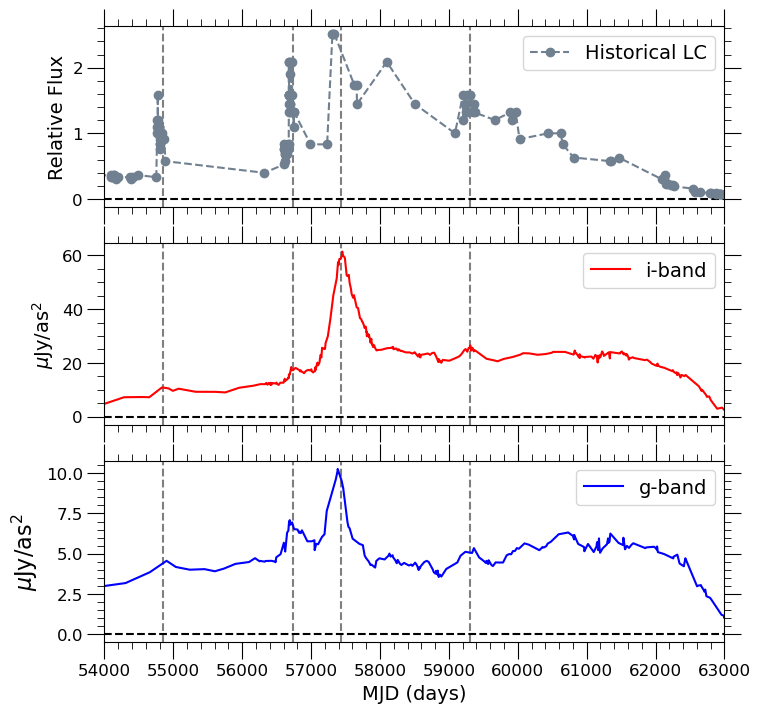

In [46]:
i_newd = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'mJyas2'], k=1))
g_newd = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'mJyas2'], k=1))


fig, axs = plt.subplots(3,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('Relative Flux', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(eta_historic.t['MJD'], eta_historic.t['Flux'], fmt='--o', ecolor='black', color='slategray', label='Historical LC')
axs[0].axhline(y=0, linestyle='--', color='black')

axs[0].axvline(54850, color='k', ls='--', alpha=0.5)
axs[0].axvline(56740, color='k', ls='--', alpha=0.5)
axs[0].axvline(57430, color='k', ls='--', alpha=0.5)
axs[0].axvline(59300, color='k', ls='--', alpha=0.5)
axs[0].set_xlim(54000, 63000)
axs[0].legend(fontsize = 14)

axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(t_ran, i_newd, fmt='-', ecolor='black', color='red', label='i-band')
axs[1].axhline(y=0, linestyle='--', color='black')

axs[1].axvline(54850, color='k', ls='--', alpha=0.5)
axs[1].axvline(56740, color='k', ls='--', alpha=0.5)
axs[1].axvline(57430, color='k', ls='--', alpha=0.5)
axs[1].axvline(59300, color='k', ls='--', alpha=0.5)
axs[1].set_xlim(54000, 63000)
axs[1].legend(fontsize = 14)

axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_xlabel('MJD (days)', fontsize = 14)
axs[2].set_ylabel('$\mu$Jy/as$^2$', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(t_ran, g_newd, fmt='-', ecolor='black', color='blue', label='g-band')
axs[2].axhline(y=0, linestyle='--', color='black')

axs[2].axvline(54850, color='k', ls='--', alpha=0.5)
axs[2].axvline(56740, color='k', ls='--', alpha=0.5)
axs[2].axvline(57430, color='k', ls='--', alpha=0.5)
axs[2].axvline(59300, color='k', ls='--', alpha=0.5)
axs[2].set_xlim(54000, 63000)
axs[2].legend(fontsize = 14)



axs[2].axvline(59350)
axs[2].axvline(60100)

# fig.savefig('../figures/display/EtaCar_Models.png', bbox_inches = 'tight', dpi = 100)

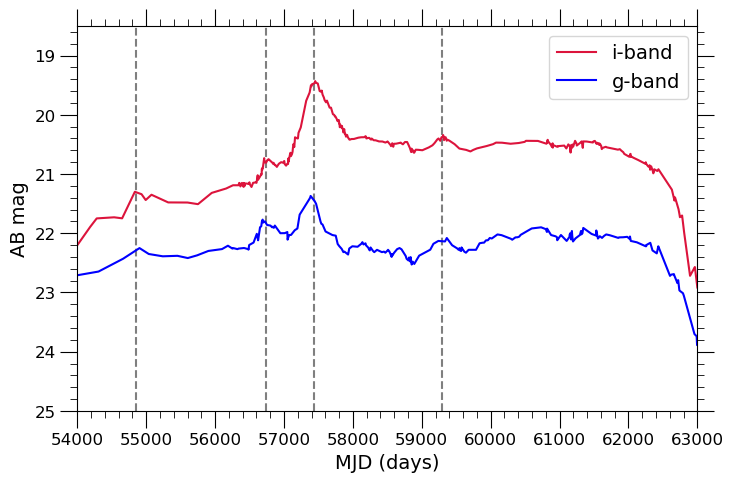

In [48]:
fig, axs = plt.subplots(dpi = 100, figsize = [8,5])
axs.minorticks_on()
axs.tick_params(axis='x', labelsize=12)
axs.tick_params(axis='y', labelsize=12)
axs.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs.set_xlabel('MJD (days)', fontsize = 14)
axs.set_ylabel('AB mag', fontsize = 14)
# axs.ticklabel_format(axis='both', style='plain')

axs.errorbar(t_ran, i_new, ecolor='black', color='crimson',label='i-band')
axs.errorbar(t_ran, g_new, ecolor='black', color='blue',label='g-band')

axs.axvline(54850, color='k', ls='--', alpha=0.5)
axs.axvline(56740, color='k', ls='--', alpha=0.5)
axs.axvline(57430, color='k', ls='--', alpha=0.5)
axs.axvline(59300, color='k', ls='--', alpha=0.5)
axs.set_xlim(54000, 63000)
axs.set_ylim(18.5, 25)
axs.invert_yaxis()
axs.legend(fontsize = 14)

fig.savefig('../figures/display/EtaCar_Mags.png', bbox_inches = 'tight', dpi = 100)